In [7]:
import pandas as pd
import os
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from matplotlib import pyplot as plt
import numpy as np

In [8]:
BASE_DIR = os.path.dirname(os.getcwd())

df = pd.read_csv(os.path.join(BASE_DIR,'data','processed','cleaned_europe_sales.csv'))
df.head(3)

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Europe,Czech Republic,Beverages,Offline,C,2011-09-12,2010-01-01,478051030,2011-09-29,4778,47.45,31.79,226716.10,151892.62,74823.48
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,2013-10-14,2010-02-01,919133651,2013-11-04,927,109.28,35.84,101302.56,33223.68,68078.88
2,Europe,Austria,Cereal,Offline,C,2014-08-13,2010-03-01,987410676,2014-09-06,5616,205.70,117.11,1155211.20,657689.76,497521.44


In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'],format='mixed')
df = df.set_index('Order Date').sort_index()

sales = df['Total Revenue']

sales

Order Date
2010-01-01    2391207.76
2010-01-01    1574016.40
2010-01-03      34204.64
2010-01-06    1302418.80
2010-01-10     438322.08
                 ...    
2017-07-17     443183.00
2017-07-18     688272.20
2017-07-20    3843862.40
2017-07-22     320265.42
2017-07-23    1061935.58
Name: Total Revenue, Length: 1330, dtype: float64

In [10]:
df.info()
df.head()
df.tail()

<class 'pandas.DataFrame'>
DatetimeIndex: 1330 entries, 2010-01-01 to 2017-07-23
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          1330 non-null   str    
 1   Country         1330 non-null   str    
 2   Item Type       1330 non-null   str    
 3   Sales Channel   1330 non-null   str    
 4   Order Priority  1330 non-null   str    
 5   Date            1330 non-null   str    
 6   Order ID        1330 non-null   int64  
 7   Ship Date       1330 non-null   str    
 8   Units Sold      1330 non-null   int64  
 9   Unit Price      1330 non-null   float64
 10  Unit Cost       1330 non-null   float64
 11  Total Revenue   1330 non-null   float64
 12  Total Cost      1330 non-null   float64
 13  Total Profit    1330 non-null   float64
dtypes: float64(5), int64(2), str(7)
memory usage: 155.9 KB


,Region,Country,Item Type,Sales Channel,Order Priority,Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
Order Date,,,,,,,,,,,,,,
2017-07-17,Europe,Macedonia,Beverages,Offline,M,2011-06-11,704139363,2017-08-31,9340,47.45,31.79,443183.00,296918.60,146264.40
2017-07-18,Europe,Kosovo,Cereal,Offline,H,2011-06-30,483655774,2017-08-05,3346,205.70,117.11,688272.20,391850.06,296422.14
2017-07-20,Europe,Switzerland,Cosmetics,Online,C,2010-02-18,233811223,2017-07-20,8792,437.20,263.33,3843862.40,2315197.36,1528665.04
2017-07-22,Europe,San Marino,Snacks,Offline,C,2011-06-05,476453721,2017-08-10,2099,152.58,97.44,320265.42,204526.56,115738.86
2017-07-23,Europe,Kosovo,Vegetables,Offline,C,2010-12-29,975080668,2017-08-20,6893,154.06,90.93,1061935.58,626780.49,435155.09


<Axes: xlabel='Order Date'>

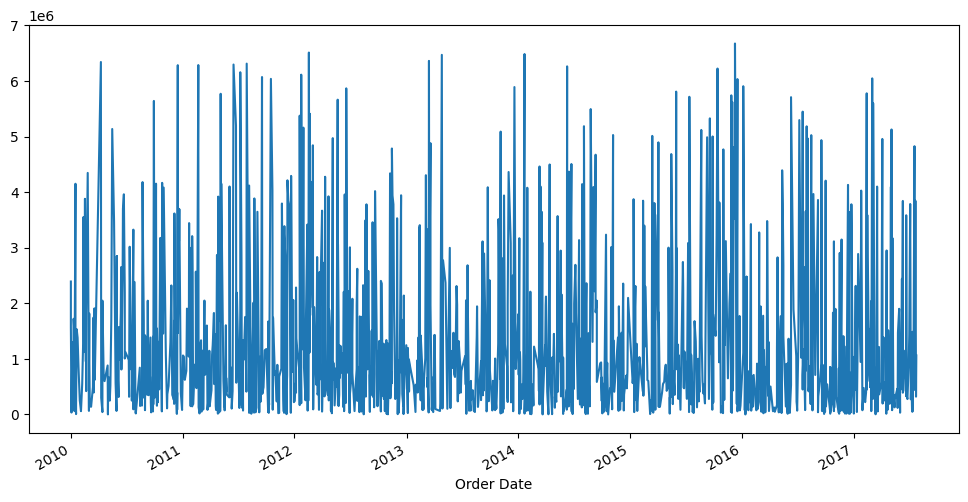

In [11]:
plt.figure(figsize=(12,6))
sales.plot()

In [12]:
# converting to month as daily data is very noisy
# 'M'  → Month end  
# 'MS' → Month start  
sales_monthly = sales.resample('ME').sum()
sales_monthly

sales_monthly_avg = sales_monthly.mean()
sales_monthly_avg

np.float64(18721125.253956042)

<Axes: xlabel='Order Date'>

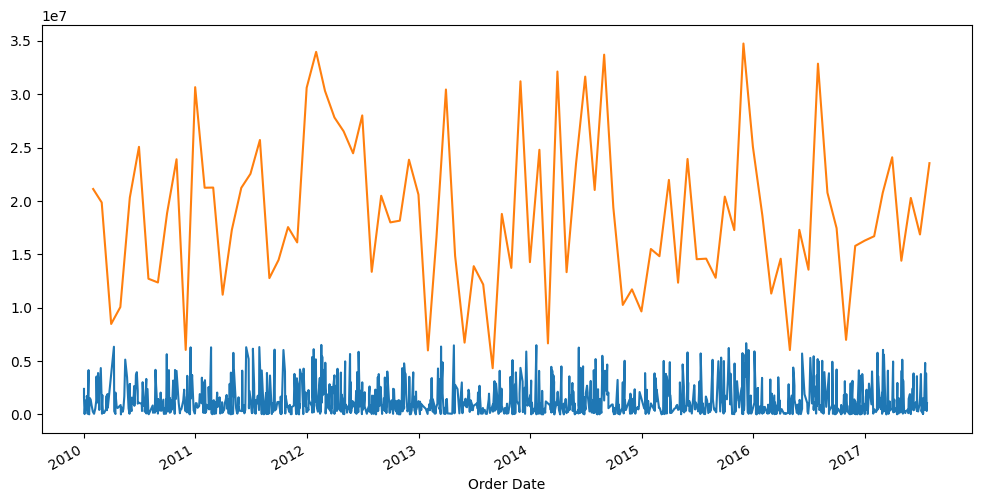

In [13]:
plt.figure(figsize=(12,6))
sales.plot()
sales_monthly.plot()

# Stationery

In [14]:
result = adfuller(sales_monthly.dropna())

result
print(f"ACF: {result[0]}")
print(f"p value: {result[1]}")

#ADF Statistic = -5.376
# p-value = 0.00000379, 
# therefore p < 0.05, which means data is stationery



ACF: -5.376473255495077
p value: 3.794690334932522e-06


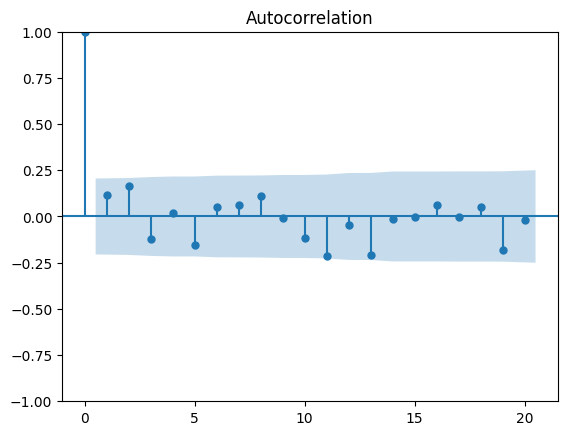

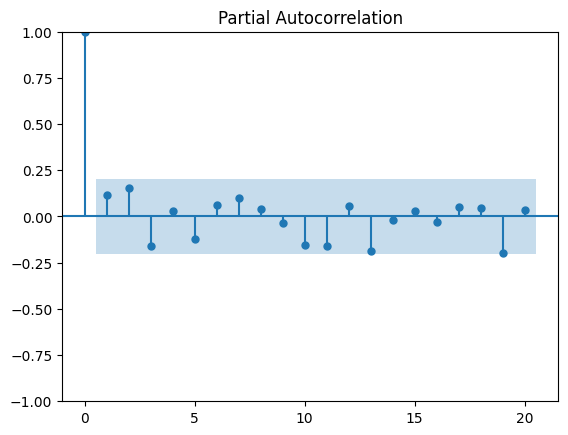

In [15]:
plot_acf(sales_monthly)
plot_pacf(sales_monthly)

plt.show()

In [16]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(sales_monthly, order=(1,0,0))
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:          Total Revenue   No. Observations:                   91
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1566.193
Date:                Thu, 02 Apr 2026   AIC                           3138.387
Time:                        14:14:14   BIC                           3145.919
Sample:                    01-31-2010   HQIC                          3141.426
                         - 07-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.872e+07   8.62e+05     21.721      0.000     1.7e+07    2.04e+07
ar.L1          0.1133      0.111      1.022      0.307      -0.104       0.331
sigma2      5.259e+13      0.019   2.76e+15      0.0

In [17]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(sales_monthly, order=(1,0,1))
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:          Total Revenue   No. Observations:                   91
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1565.919
Date:                Thu, 02 Apr 2026   AIC                           3139.837
Time:                        14:14:14   BIC                           3149.881
Sample:                    01-31-2010   HQIC                          3143.889
                         - 07-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.872e+07   9.33e+05     20.076      0.000    1.69e+07    2.05e+07
ar.L1          0.4343      0.691      0.628      0.530      -0.920       1.789
ma.L1         -0.3099      0.734     -0.422      0.6

In [18]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(sales_monthly, order=(0,0,1))
result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:          Total Revenue   No. Observations:                   91
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1566.340
Date:                Thu, 02 Apr 2026   AIC                           3138.681
Time:                        14:14:14   BIC                           3146.213
Sample:                    01-31-2010   HQIC                          3141.720
                         - 07-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.872e+07   8.26e+05     22.663      0.000    1.71e+07    2.03e+07
ma.L1          0.0842      0.109      0.775      0.438      -0.129       0.297
sigma2      5.248e+13      0.018   2.98e+15      0.0

In [19]:
from statsmodels.tsa.arima.model import ARIMA

# Model
model = ARIMA(sales_monthly, order=(0,0,0))
result = model.fit()

print(result.summary())

# Forecast
forecast = result.get_forecast(steps=6)
forecast_df = forecast.summary_frame()

forecast_df.rename(columns={
    'mean': 'Forecast',
    'mean_ci_lower': 'Lower Bound',
    'mean_ci_upper': 'Upper Bound'
}, inplace=True)

print(forecast_df)

                               SARIMAX Results                                
Dep. Variable:          Total Revenue   No. Observations:                   91
Model:                          ARIMA   Log Likelihood               -1727.026
Date:                Thu, 02 Apr 2026   AIC                           3458.053
Time:                        14:14:14   BIC                           3463.074
Sample:                    01-31-2010   HQIC                          3460.078
                         - 07-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.872e+07   6.93e+07      0.270      0.787   -1.17e+08    1.55e+08
sigma2      4.802e+15   1.02e+15      4.718      0.000    2.81e+15     6.8e+15
Ljung-Box (L1) (Q):                   1.22   Jarque-

In [20]:

print(forecast_df)

Total Revenue      Forecast       mean_se   Lower Bound   Upper Bound
2017-08-31     1.872113e+07  6.929460e+07 -1.170938e+08  1.545360e+08
2017-09-30     1.872113e+07  6.929460e+07 -1.170938e+08  1.545360e+08
2017-10-31     1.872113e+07  6.929460e+07 -1.170938e+08  1.545360e+08
2017-11-30     1.872113e+07  6.929460e+07 -1.170938e+08  1.545360e+08
2017-12-31     1.872113e+07  6.929460e+07 -1.170938e+08  1.545360e+08
2018-01-31     1.872113e+07  6.929460e+07 -1.170938e+08  1.545360e+08
